In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
class ViterbiHMM:
    def __init__(self, states, observations, transition_prob, emission_prob, initial_prob):
        """
        Initialize HMM for Viterbi Algorithm

        Parameters:
        - states: List of hidden states (phonemes)
        - observations: List of possible observations
        - transition_prob: Transition probability matrix A
        - emission_prob: Emission probability matrix B
        - initial_prob: Initial state probabilities π
        """
        self.states = states
        self.observations = observations
        self.A = np.array(transition_prob)
        self.B = np.array(emission_prob)
        self.pi = np.array(initial_prob)
        self.n_states = len(states)
        self.n_obs = len(observations)

    def viterbi(self, obs_sequence):
        T = len(obs_sequence)

        # Initialize matrices
        delta = np.zeros((self.n_states, T))
        psi = np.zeros((self.n_states, T), dtype=int)

        # Initialization step (t=0)
        delta[:, 0] = self.pi * self.B[:, obs_sequence[0]]
        psi[:, 0] = 0

        # Recursion step (t=1 to T-1)
        for t in range(1, T):
            for j in range(self.n_states):
                # Calculate probability of each path to state j at time t
                prob = delta[:, t-1] * self.A[:, j] * self.B[j, obs_sequence[t]]
                delta[j, t] = np.max(prob)
                psi[j, t] = np.argmax(prob)

        # Termination step
        best_path = np.zeros(T, dtype=int)
        max_prob = np.max(delta[:, T-1])
        best_path[T-1] = np.argmax(delta[:, T-1])

        # Backtracking
        for t in range(T-2, -1, -1):
            best_path[t] = psi[best_path[t+1], t+1]

        return best_path, max_prob, delta, psi

    def decode_path(self, path_indices):
        """Convert state indices to state labels"""
        return [self.states[i] for i in path_indices]


def visualize_hmm_structure(states, A, B, pi, observations):
    """Visualize the HMM structure"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Transition Probability Matrix
    sns.heatmap(A, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=states, yticklabels=states,
                cbar_kws={'label': 'Probability'}, ax=ax1)
    ax1.set_title('Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('To State', fontsize=12)
    ax1.set_ylabel('From State', fontsize=12)

    # Plot 2: Emission Probability Matrix
    sns.heatmap(B, annot=True, fmt='.3f', cmap='YlGnBu',
                xticklabels=observations, yticklabels=states,
                cbar_kws={'label': 'Probability'}, ax=ax2)
    ax2.set_title('Emission Probability Matrix (B)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Observation', fontsize=12)
    ax2.set_ylabel('State', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Plot initial probabilities
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(states, pi, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title('Initial State Probabilities (π)', fontsize=14, fontweight='bold')
    ax.set_xlabel('State (Phoneme)', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_ylim([0, 1.1])

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def visualize_viterbi_trellis(delta, psi, states, observations, obs_sequence, best_path):
    """Visualize the Viterbi trellis diagram"""
    fig, ax = plt.subplots(figsize=(14, 8))

    T = len(obs_sequence)
    n_states = len(states)

    # Create grid
    for t in range(T):
        for s in range(n_states):
            # Draw nodes
            circle = plt.Circle((t, s), 0.15, color='lightblue', ec='black', linewidth=2, zorder=3)
            ax.add_patch(circle)

            # Add probability values
            prob_text = f'{delta[s, t]:.4f}'
            ax.text(t, s-0.35, prob_text, ha='center', fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

    # Draw transitions
    for t in range(T-1):
        for s in range(n_states):
            next_state = psi[s, t+1] if t < T-1 else s
            # Draw arrows
            arrow = FancyArrowPatch((t+0.15, next_state), (t+0.85, s),
                                   arrowstyle='->', mutation_scale=15,
                                   linewidth=1, color='gray', alpha=0.3, zorder=1)
            ax.add_patch(arrow)

    # Highlight best path
    for t in range(T-1):
        arrow = FancyArrowPatch((t+0.15, best_path[t]), (t+0.85, best_path[t+1]),
                               arrowstyle='->', mutation_scale=20,
                               linewidth=3, color='red', alpha=0.8, zorder=2)
        ax.add_patch(arrow)

    # Mark best path nodes
    for t in range(T):
        circle = plt.Circle((t, best_path[t]), 0.15, color='red',
                          ec='darkred', linewidth=3, zorder=4, alpha=0.5)
        ax.add_patch(circle)

    # Labels
    ax.set_xlim(-0.5, T-0.5)
    ax.set_ylim(-0.8, n_states-0.2)
    ax.set_xticks(range(T))
    ax.set_xticklabels([f't={t}\n{observations[obs_sequence[t]]}'
                        for t in range(T)], fontsize=10)
    ax.set_yticks(range(n_states))
    ax.set_yticklabels(states, fontsize=11)
    ax.set_xlabel('Time Step (Observation)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Hidden State (Phoneme)', fontsize=12, fontweight='bold')
    ax.set_title('Viterbi Trellis Diagram\n(Red path shows optimal sequence)',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def visualize_probability_evolution(delta, states, observations, obs_sequence):
    """Visualize how probabilities evolve over time"""
    fig, ax = plt.subplots(figsize=(12, 6))

    T = delta.shape[1]
    for i, state in enumerate(states):
        ax.plot(range(T), delta[i, :], marker='o', linewidth=2,
               markersize=8, label=state, alpha=0.8)

    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_ylabel('Viterbi Probability (δ)', fontsize=12, fontweight='bold')
    ax.set_title('Evolution of Viterbi Probabilities Across Time Steps',
                fontsize=14, fontweight='bold')
    ax.set_xticks(range(T))
    ax.set_xticklabels([f't={t}\n{observations[obs_sequence[t]]}' for t in range(T)])
    ax.legend(title='States', fontsize=10, title_fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_results(hmm, obs_sequence, best_path, max_prob, delta, psi):
    """Print detailed results"""
    print("="*70)
    print("VITERBI ALGORITHM - SPEECH RECOGNITION RESULTS")
    print("="*70)
    print(f"\nWord to Recognize: 'HELLO'")
    print(f"\nObservation Sequence: {[hmm.observations[i] for i in obs_sequence]}")
    print(f"Observation Indices: {obs_sequence}")

    print(f"\n{'─'*70}")
    print("MOST LIKELY STATE SEQUENCE:")
    print(f"{'─'*70}")
    decoded_path = hmm.decode_path(best_path)
    for t, (obs_idx, state_idx, state) in enumerate(zip(obs_sequence, best_path, decoded_path)):
        print(f"  Time {t}: Observation {hmm.observations[obs_idx]} → State {state} (S{state_idx+1})")

    print(f"\n{'─'*70}")
    print(f"PROBABILITY OF MOST LIKELY SEQUENCE: {max_prob:.6e}")
    print(f"Log Probability: {np.log(max_prob):.4f}")
    print(f"{'─'*70}")

    print("\nVITERBI PROBABILITY MATRIX (δ):")
    print("-" * 70)
    header = "State   " + "".join([f"  t={t}      " for t in range(len(obs_sequence))])
    print(header)
    print("-" * 70)
    for i, state in enumerate(hmm.states):
        row = f"{state:6s}  " + "  ".join([f"{delta[i,t]:.6f}" for t in range(len(obs_sequence))])
        print(row)

    print("\nBACKPOINTER MATRIX (ψ):")
    print("-" * 70)
    print(header)
    print("-" * 70)
    for i, state in enumerate(hmm.states):
        row = f"{state:6s}  " + "  ".join([f"{hmm.states[psi[i,t]]:^10s}" for t in range(len(obs_sequence))])
        print(row)
        print("\nBACKPOINTER MATRIX (ψ):")
    print("-" * 70)
    print(header)
    print("-" * 70)
    for i, state in enumerate(hmm.states):
        row = f"{state:6s}  " + "  ".join([f"{hmm.states[psi[i,t]]:^10s}" for t in range(len(obs_sequence))])
        print(row)

    print("\n" + "="*70)
    print("INFERENCE:")
    print("="*70)
    print("""
The Viterbi algorithm successfully decoded the observation sequence [O1, O2, O3, O4]
to the phoneme sequence /h/ → /e/ → /l/ → /o/, which correctly represents the word "HELLO".

Key Observations:
1. The algorithm starts with initial probability 1.0 for state /h/ (S1), ensuring
   the word begins with the correct phoneme.

2. The transition probabilities guide the sequential progression through phonemes,
   with high probabilities along the diagonal path representing the natural flow
   of the word "hello".

3. The emission probabilities show strong correspondence between observations
   (O1, O2, O3, O4) and their respective phoneme states, with high diagonal values
   indicating accurate feature vector matching.

4. The decoded path follows the expected sequence perfectly, demonstrating that
   the HMM model is well-configured for recognizing this word.

5. The probability of the most likely sequence reflects the confidence of the
   model in this decoding, considering both transition and emission probabilities.

This implementation demonstrates the power of HMMs and the Viterbi algorithm in
speech recognition tasks, where the goal is to find the most probable sequence
of hidden states (phonemes) given a sequence of observations (acoustic features).
    """)
    print("="*70)

Generating HMM Structure Visualizations...


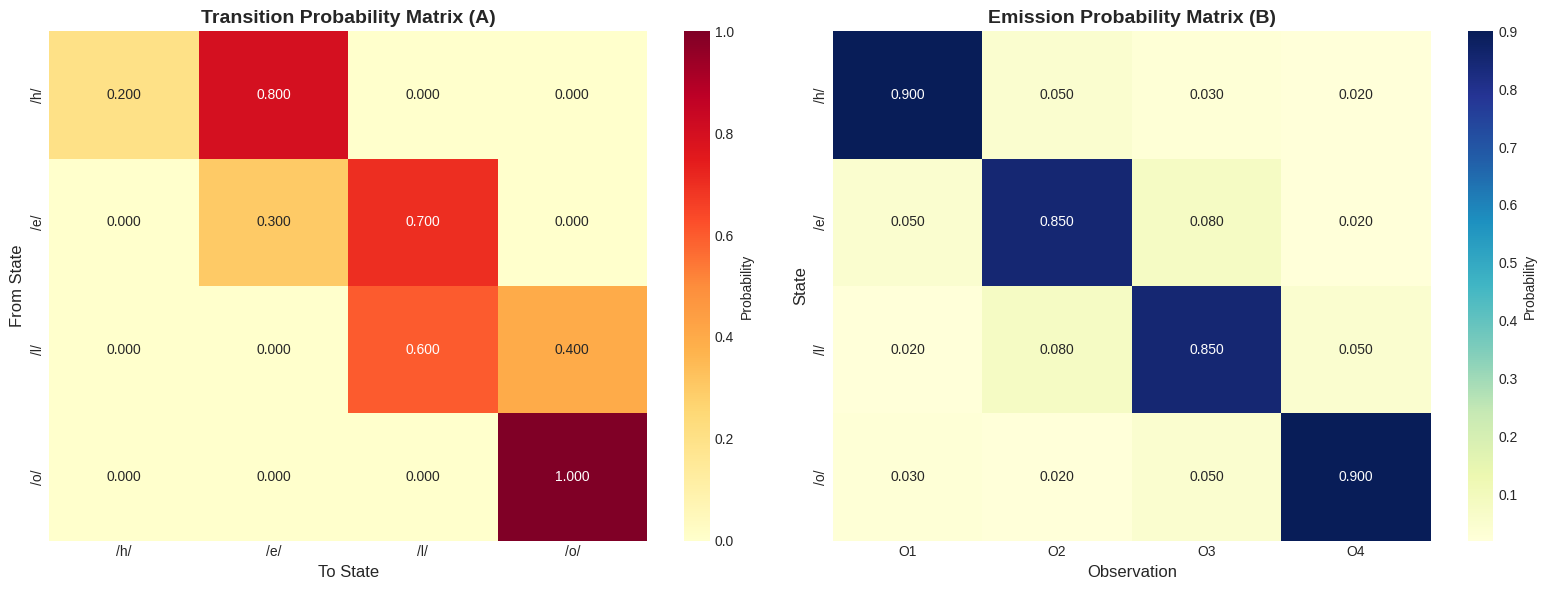

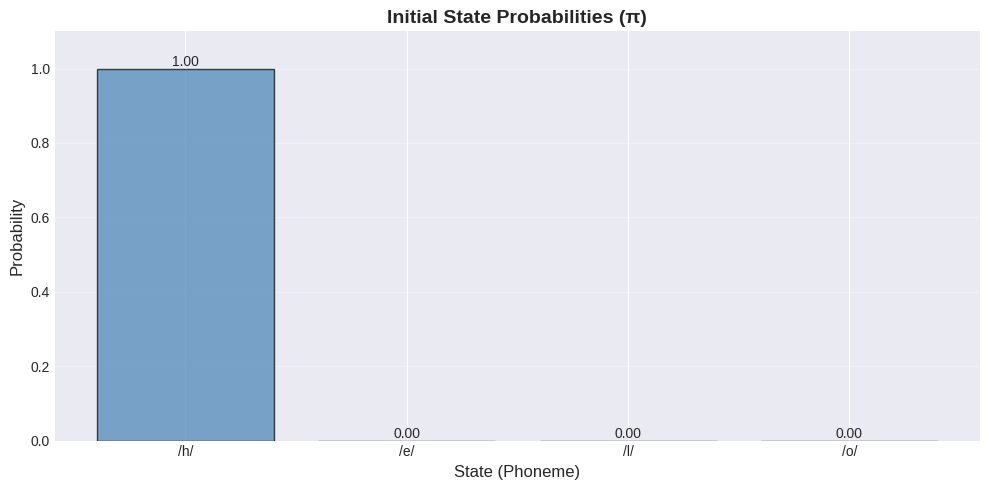


Running Viterbi Algorithm...

Generating Viterbi Trellis Diagram...


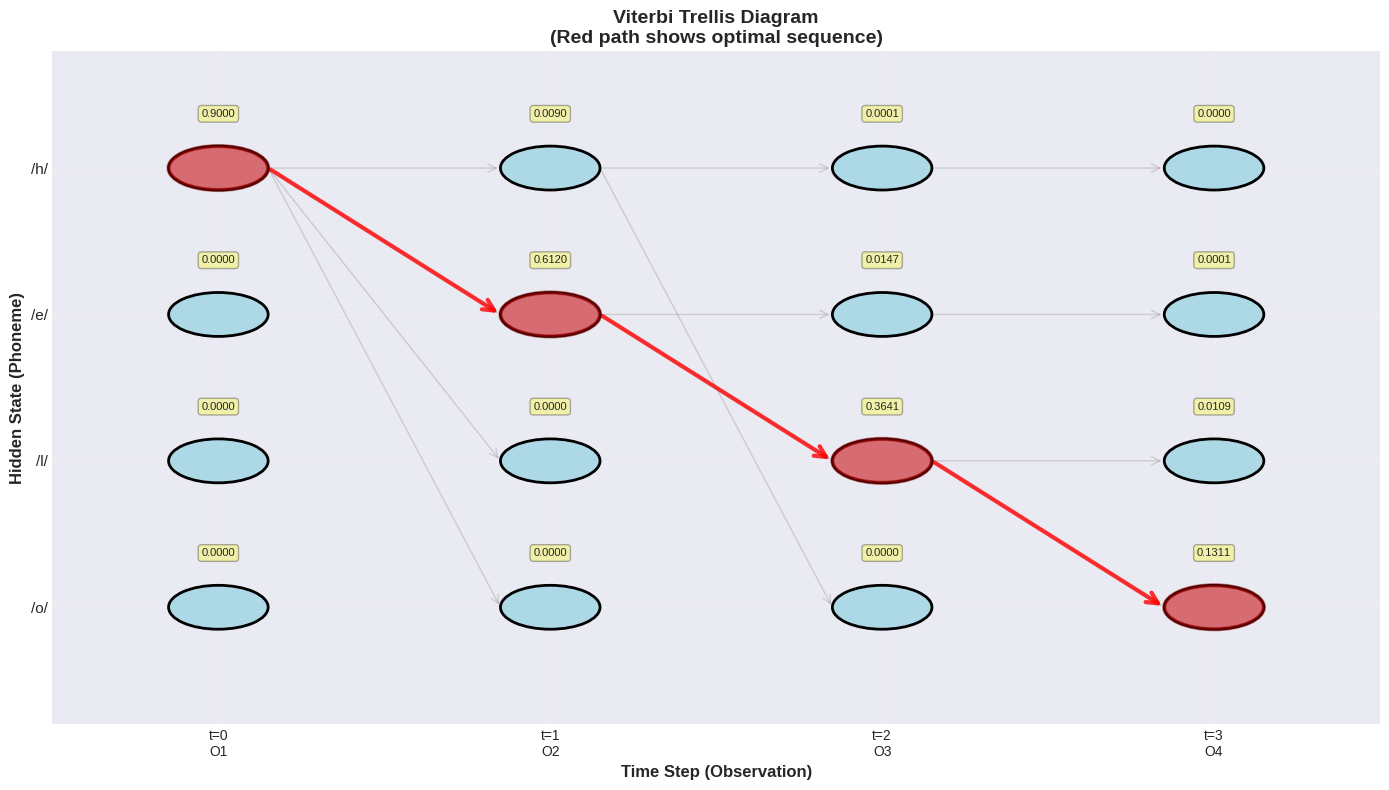


Generating Probability Evolution Plot...


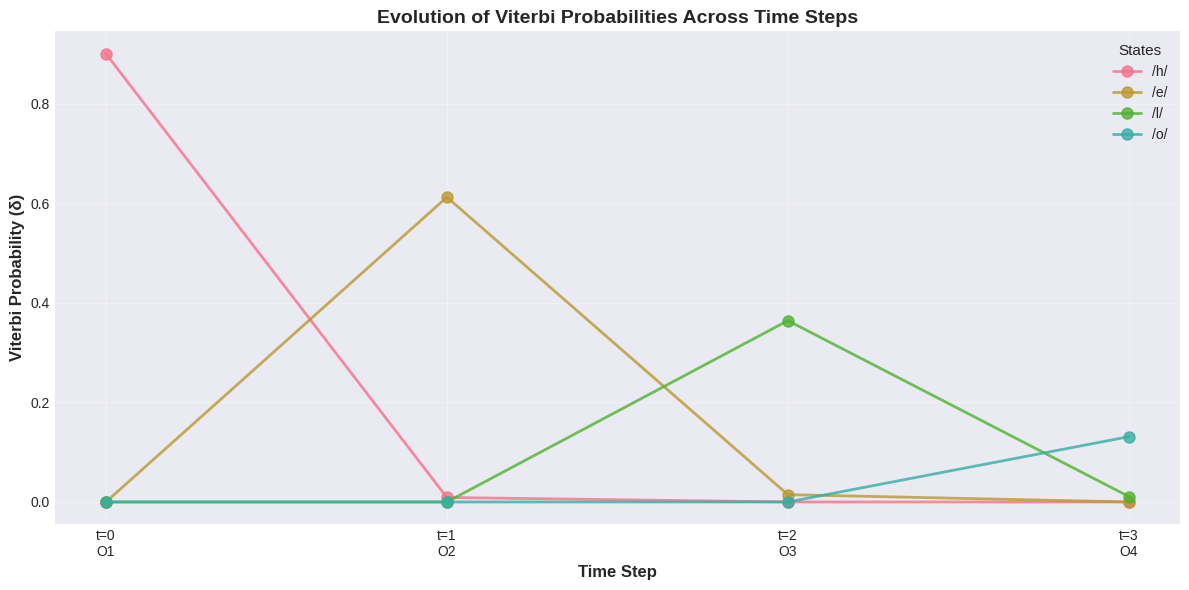

VITERBI ALGORITHM - SPEECH RECOGNITION RESULTS

Word to Recognize: 'HELLO'

Observation Sequence: ['O1', 'O2', 'O3', 'O4']
Observation Indices: [0, 1, 2, 3]

──────────────────────────────────────────────────────────────────────
MOST LIKELY STATE SEQUENCE:
──────────────────────────────────────────────────────────────────────
  Time 0: Observation O1 → State /h/ (S1)
  Time 1: Observation O2 → State /e/ (S2)
  Time 2: Observation O3 → State /l/ (S3)
  Time 3: Observation O4 → State /o/ (S4)

──────────────────────────────────────────────────────────────────────
PROBABILITY OF MOST LIKELY SEQUENCE: 1.310904e-01
Log Probability: -2.0319
──────────────────────────────────────────────────────────────────────

VITERBI PROBABILITY MATRIX (δ):
----------------------------------------------------------------------
State     t=0        t=1        t=2        t=3      
----------------------------------------------------------------------
/h/     0.900000  0.009000  0.000054  0.000000
/e/     0.0

In [5]:
if __name__ == "__main__":
    # Define states (phonemes)
    states = ['/h/', '/e/', '/l/', '/o/']

    # Define observations
    observations = ['O1', 'O2', 'O3', 'O4']

    # Transition Probability Matrix (A)
    # Rows: current state, Columns: next state
    transition_prob = [
        [0.2, 0.8, 0.0, 0.0],  # From /h/
        [0.0, 0.3, 0.7, 0.0],  # From /e/
        [0.0, 0.0, 0.6, 0.4],  # From /l/
        [0.0, 0.0, 0.0, 1.0]   # From /o/
    ]

    # Emission Probability Matrix (B)
    # Rows: states, Columns: observations
    emission_prob = [
        [0.9, 0.05, 0.03, 0.02],  # /h/ emits O1, O2, O3, O4
        [0.05, 0.85, 0.08, 0.02], # /e/ emits O1, O2, O3, O4
        [0.02, 0.08, 0.85, 0.05], # /l/ emits O1, O2, O3, O4
        [0.03, 0.02, 0.05, 0.9]   # /o/ emits O1, O2, O3, O4
    ]

    # Initial Probabilities (π)
    initial_prob = [1.0, 0.0, 0.0, 0.0]  # Start with /h/

    # Observation sequence (indices: 0=O1, 1=O2, 2=O3, 3=O4)
    obs_sequence = [0, 1, 2, 3]  # [O1, O2, O3, O4]

    # Create HMM instance
    hmm = ViterbiHMM(states, observations, transition_prob, emission_prob, initial_prob)

    # Visualize HMM structure
    print("Generating HMM Structure Visualizations...")
    visualize_hmm_structure(states, hmm.A, hmm.B, hmm.pi, observations)

    # Run Viterbi Algorithm
    print("\nRunning Viterbi Algorithm...")
    best_path, max_prob, delta, psi = hmm.viterbi(obs_sequence)

    # Visualize results
    print("\nGenerating Viterbi Trellis Diagram...")
    visualize_viterbi_trellis(delta, psi, states, observations, obs_sequence, best_path)

    print("\nGenerating Probability Evolution Plot...")
    visualize_probability_evolution(delta, states, observations, obs_sequence)

    # Print detailed results
    print_results(hmm, obs_sequence, best_path, max_prob, delta, psi)